# Variational AutoEncoder

**Author:** [fchollet](https://twitter.com/fchollet)<br>
**Date created:** 2020/05/03<br>
**Last modified:** 2024/04/24<br>
**Description:** Convolutional Variational AutoEncoder (VAE) trained on MNIST digits.

## Setup

In [54]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

## Create a sampling layer

In [55]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.random_generator = tf.random.Generator.from_seed(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = self.random_generator.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [56]:
# Load and preprocess the MNIST dataset with color images
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
mnist_digits_train = np.expand_dims(x_train, -1)  # Add a dimension for color channel
mnist_digits_train = np.tile(mnist_digits_train, (1, 1, 1, 3))  # Tile the grayscale image to create a 3-channel image
mnist_digits_train = mnist_digits_train.astype("float32") / 255

## Build the encoder

In [57]:
# Define the latent dimension
latent_dim = 2

# Define the encoder
encoder_inputs = tf.keras.Input(shape=(28, 28, 3))
x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation="relu")(x)
z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = tf.keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 conv2d_10 (Conv2D)             (None, 14, 14, 32)   896         ['input_13[0][0]']               
                                                                                                  
 conv2d_11 (Conv2D)             (None, 7, 7, 64)     18496       ['conv2d_10[0][0]']              
                                                                                                  
 flatten_5 (Flatten)            (None, 3136)         0           ['conv2d_11[0][0]']              
                                                                                            

## Build the decoder

In [58]:
# Define the decoder
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)  # Output 3 channels for RGB
decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_14 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_11 (Dense)            (None, 3136)              9408      
                                                                 
 reshape_5 (Reshape)         (None, 7, 7, 64)          0         
                                                                 
 conv2d_transpose_15 (Conv2D  (None, 14, 14, 64)       36928     
 Transpose)                                                      
                                                                 
 conv2d_transpose_16 (Conv2D  (None, 28, 28, 32)       18464     
 Transpose)                                                      
                                                                 
 conv2d_transpose_17 (Conv2D  (None, 28, 28, 3)        867 

## Define the VAE as a `Model` with a custom `train_step`

In [59]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Flatten the input data and decoder output
            data_flattened = tf.keras.layers.Flatten()(data)
            reconstruction_flattened = tf.keras.layers.Flatten()(reconstruction)

            # Compute binary cross-entropy loss
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data_flattened, reconstruction_flattened)
            )

            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## Train the VAE

In [60]:
# Reshape input data to match decoder output shape
mnist_digits_train_resized = np.expand_dims(mnist_digits_train, axis=-1)

# Define the VAE model
vae = VAE(encoder, decoder)

# Compile and train the VAE model
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(mnist_digits_train, epochs=50, batch_size=128)

Epoch 1/50
469/469 [==============================] - 36s 72ms/step - loss: 0.3483 - reconstruction_loss: 0.2878 - kl_loss: 3.2999e-05
Epoch 2/50
469/469 [==============================] - 33s 70ms/step - loss: 0.2635 - reconstruction_loss: 0.2635 - kl_loss: 1.4488e-08
Epoch 3/50
469/469 [==============================] - 32s 69ms/step - loss: 0.2629 - reconstruction_loss: 0.2632 - kl_loss: 7.4347e-09
Epoch 4/50
469/469 [==============================] - 35s 74ms/step - loss: 0.2627 - reconstruction_loss: 0.2631 - kl_loss: 9.6587e-09
Epoch 5/50
469/469 [==============================] - 35s 74ms/step - loss: 0.2633 - reconstruction_loss: 0.2631 - kl_loss: 5.1471e-09
Epoch 6/50
469/469 [==============================] - 35s 75ms/step - loss: 0.2632 - reconstruction_loss: 0.2631 - kl_loss: 1.6649e-08
Epoch 7/50
469/469 [==============================] - 38s 81ms/step - loss: 0.2630 - reconstruction_loss: 0.2631 - kl_loss: 2.3067e-08
Epoch 8/50
469/469 [==============================] - 3

## Display a grid of sampled digits

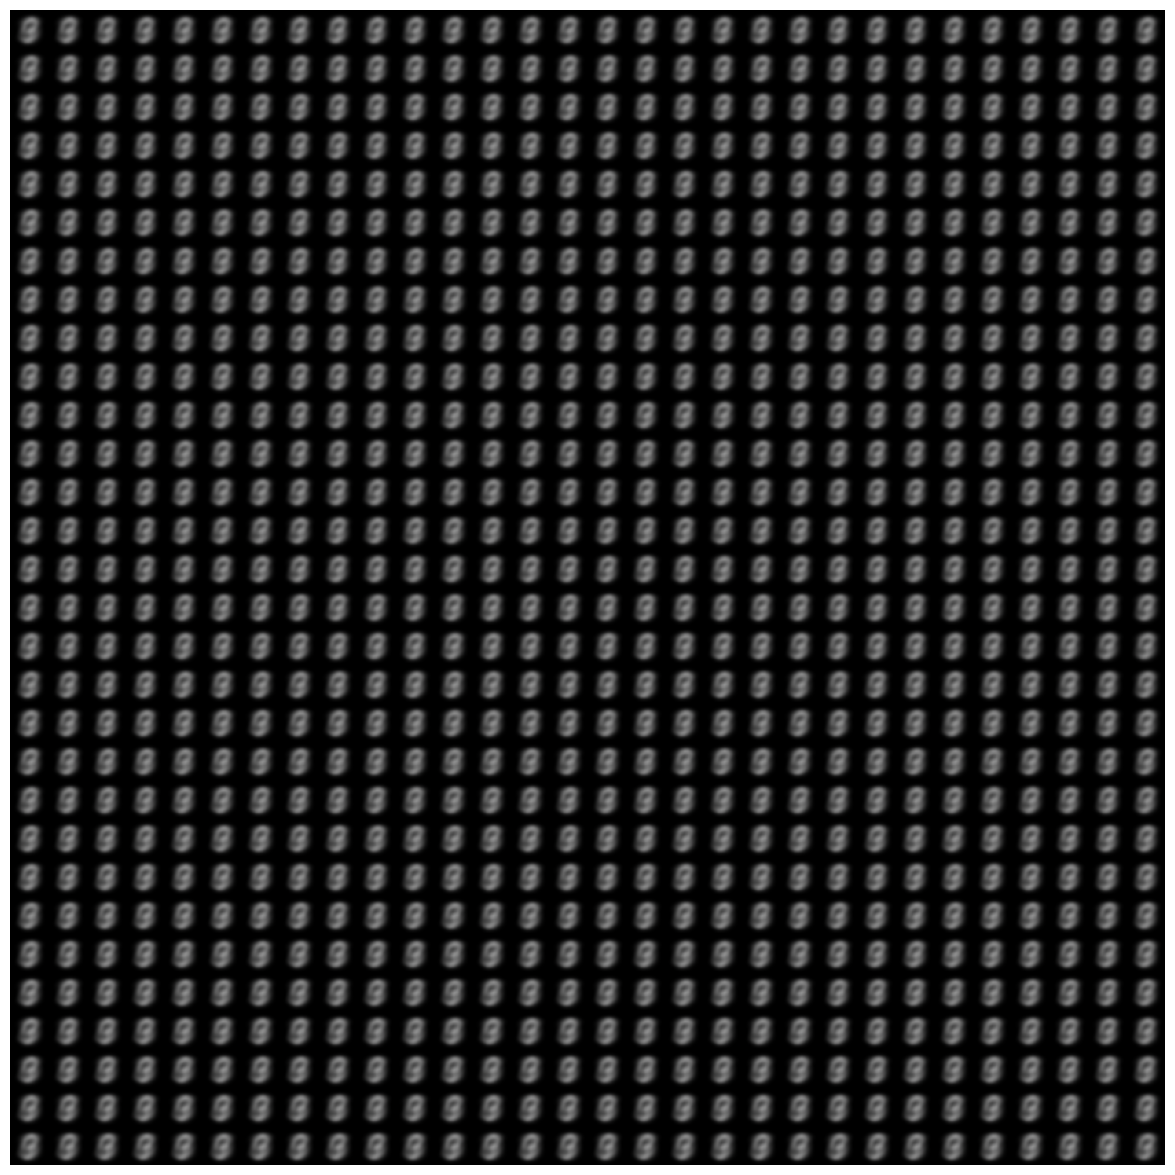

In [61]:
# Visualization functions
import matplotlib.pyplot as plt

def plot_latent_space(vae, n=30, figsize=15):
    # Display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n, 3))  # Initialize array for color images
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size, 3)  # Reshape output to match color image format
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
                :
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure)
    plt.axis("off")
    plt.show()

plot_latent_space(vae)

In [62]:
import ipywidgets as widgets
from IPython.display import display

def visualize_character(x_seed, y_seed):
    z_sample = np.array([[x_seed, y_seed]])
    x_decoded = vae.decoder.predict(z_sample)
    plt.imshow(x_decoded[0])
    plt.axis('off')
    plt.show()

x_seed_widget = widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='X Seed:')
y_seed_widget = widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='Y Seed:')

interactive_plot = widgets.interactive(visualize_character, x_seed=x_seed_widget, y_seed=y_seed_widget)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='X Seed:', max=3.0, min=-3.0), FloatSlider(value=0.0,…